In [8]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

In [21]:
# ==============================
# 2. DATASET PATH
# ==============================

DATASET_PATH = r"C:\Users\Lenovo\Desktop\projects M1\plant-disease-ai\datasets"

classes = os.listdir(DATASET_PATH)

print("Classes détectées :")
print(classes)

Classes détectées :
['Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight']


In [22]:
# ==============================
# 3. CLASS DISTRIBUTION
# ==============================

class_counts = {}

for class_name in classes:
    class_path = os.path.join(DATASET_PATH, class_name)

    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[class_name] = num_images

# Convert to DataFrame
df_classes = pd.DataFrame({
    "Class": class_counts.keys(),
    "Number_of_Images": class_counts.values()
})

df_classes

,Class,Number_of_Images
0,Potato___Early_blight,1000
1,Potato___healthy,152
2,Potato___Late_blight,1000
3,Tomato_Early_blight,1000
4,Tomato_healthy,1591
5,Tomato_Late_blight,1909


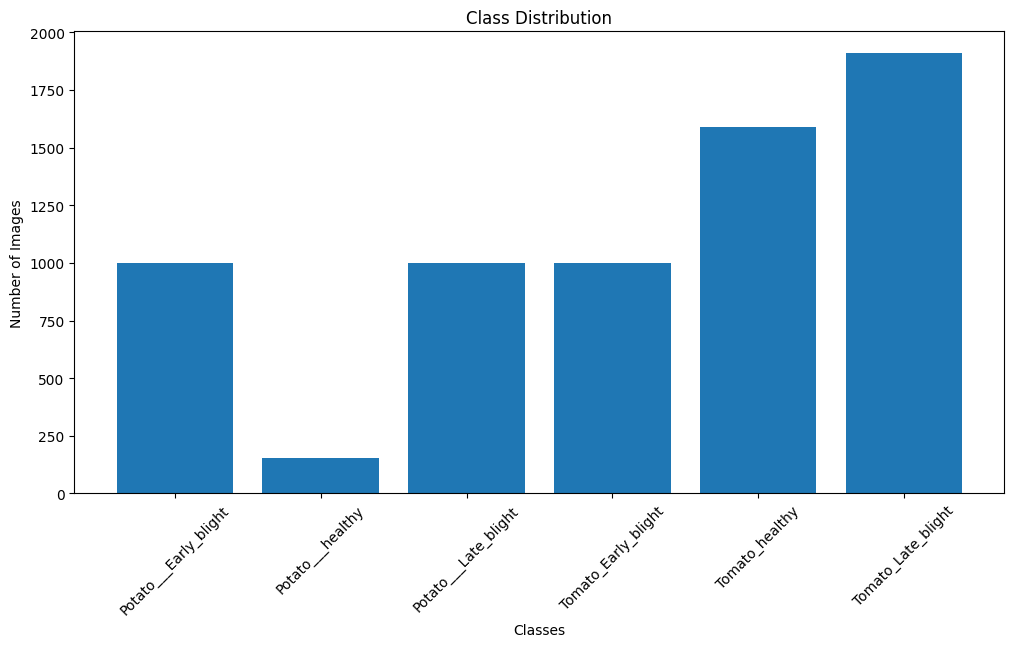

In [23]:
# ==============================
# 4. VISUALIZE CLASS DISTRIBUTION
# ==============================

plt.figure(figsize=(12,6))

plt.bar(df_classes["Class"], df_classes["Number_of_Images"])

plt.xticks(rotation=45)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.show()

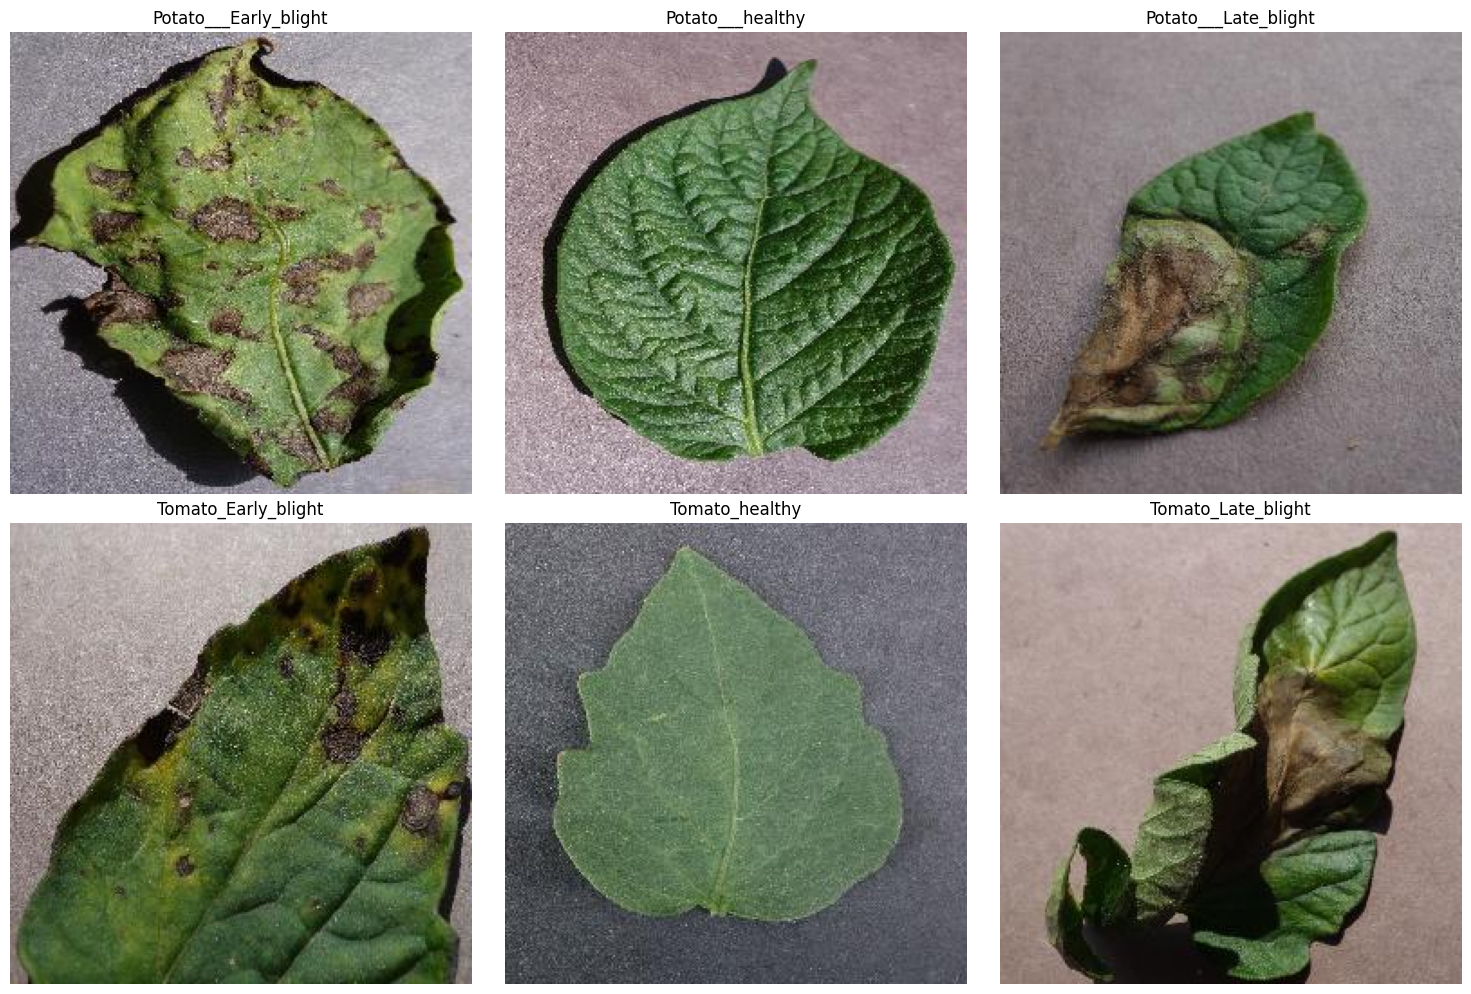

In [24]:
# ==============================
# 5. DISPLAY SAMPLE IMAGES
# ==============================

plt.figure(figsize=(15,10))

for i, class_name in enumerate(classes):

    class_path = os.path.join(DATASET_PATH, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
# ==============================
# 6. CHECK CORRUPTED IMAGES
# ==============================

corrupted_images = []

for class_name in classes:

    class_path = os.path.join(DATASET_PATH, class_name)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        try:
            img = Image.open(image_path)
            img.verify()

        except Exception:
            corrupted_images.append(image_path)

print(f"Nombre d'images corrompues : {len(corrupted_images)}")

Nombre d'images corrompues : 0


In [26]:
# ==============================
# 7. IMAGE SIZE ANALYSIS
# ==============================

image_sizes = []

for class_name in classes:

    class_path = os.path.join(DATASET_PATH, class_name)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        image = cv2.imread(image_path)

        if image is not None:
            h, w, _ = image.shape
            image_sizes.append((w, h))

# Convert to DataFrame
df_sizes = pd.DataFrame(image_sizes, columns=["Width", "Height"])

df_sizes.head()

,Width,Height
0,256,256
1,256,256
2,256,256
3,256,256
4,256,256


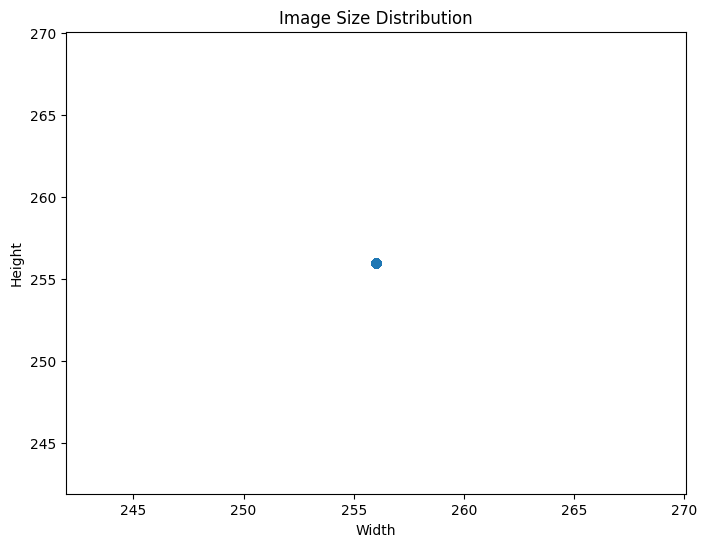

In [27]:
# ==============================
# 8. IMAGE SIZE DISTRIBUTION
# ==============================

plt.figure(figsize=(8,6))

plt.scatter(df_sizes["Width"], df_sizes["Height"])

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")

plt.show()
